<a href="https://colab.research.google.com/github/zinebidrissijanati1-debug/ERF-REPO/blob/main/Comparision__baseline_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset: WDBC | 569 samples | 30 features
Class balance: 357 malignant / 212 benign

──────────────────────────────────────────────────────────────────────
Evaluating baseline classifiers on all 30 features…
──────────────────────────────────────────────────────────────────────
  ✓ RF (all features, default)     Acc=0.9596  AUC=0.9909  (0.026 min)

  [Tuning] Grid-searching Random Forest… done in 2.44 min
  Best RF params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 100}
  ✓ RF (optimized)                 Acc=0.9578  AUC=0.9899  (0.014 min)
  ✓ SVM (RBF, scaled)              Acc=0.9789  AUC=0.9944  (0.001 min)
  ✓ Gradient Boosting              Acc=0.9666  AUC=0.9926  (0.042 min)
  ✓ XGBoost                        Acc=0.9666  AUC=0.9921  (0.005 min)

  [Regenerating ERF ROC curve from selected features for the plot]

COMPARISON TABLE — Reviewer 1, Suggestion 1
Method                               Acc   BalAcc    Prec     Rec      F1     AUC   Tim

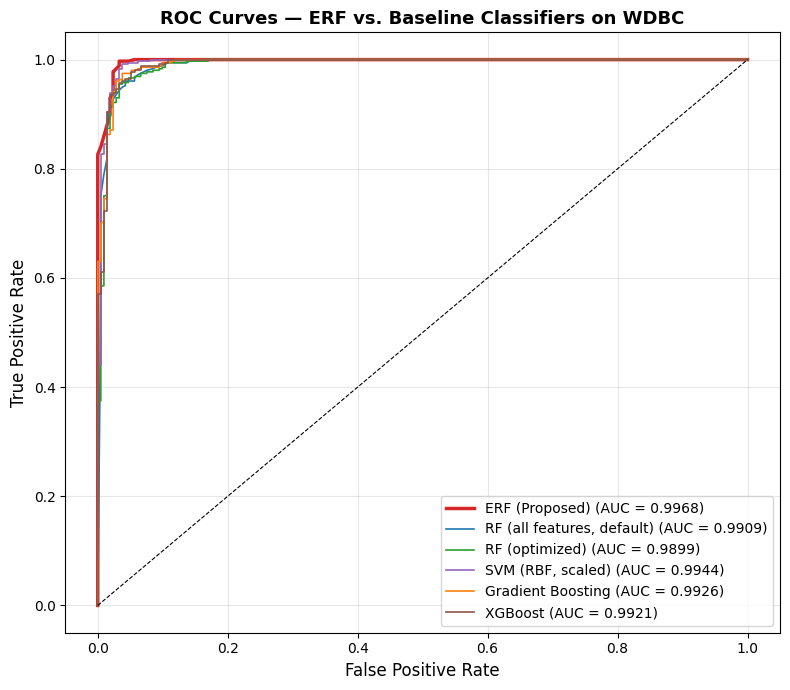

[Saved] baselines_roc_comparison.pdf / .png — ROC plot for paper

✓ Reviewer 1, Suggestion 1 — baseline comparison complete.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[INFO] XGBoost not installed. To enable: pip install xgboost")

# ---------------------------------------------------------------------------
# 1. Load the SAME dataset as your ERF experiment
# ---------------------------------------------------------------------------
data = load_breast_cancer()
X, y = data.data, data.target
random_state = 0          # ← SAME seed as your ERF
n_splits     = 5          # ← SAME CV as your ERF

print(f"Dataset: WDBC | {X.shape[0]} samples | {X.shape[1]} features")
print(f"Class balance: {(y==1).sum()} malignant / {(y==0).sum()} benign\n")


# ---------------------------------------------------------------------------
# 2. Generic evaluation function — uses the SAME CV splits as ERF
# ---------------------------------------------------------------------------
def evaluate_model(model, X, y, name):
    """5-fold CV evaluation matching the ERF protocol."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_preds, all_probs, all_true = [], [], []
    t0 = time.time()

    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        all_preds.extend(model.predict(X[te]))
        all_probs.extend(model.predict_proba(X[te])[:, 1])
        all_true.extend(y[te])

    elapsed = (time.time() - t0) / 60
    at, ap, ab = map(np.array, [all_true, all_preds, all_probs])
    fpr, tpr, _ = roc_curve(at, ab)

    metrics = {
        "Method"        : name,
        "Accuracy"      : accuracy_score(at, ap),
        "Balanced_Acc"  : balanced_accuracy_score(at, ap),
        "Precision"     : precision_score(at, ap),
        "Recall"        : recall_score(at, ap),
        "F1"            : f1_score(at, ap),
        "AUC"           : roc_auc_score(at, ab),
        "Time_min"      : elapsed,
        "fpr"           : fpr,
        "tpr"           : tpr,
        "cm"            : confusion_matrix(at, ap),
    }
    print(f"  ✓ {name:30s} Acc={metrics['Accuracy']:.4f}  "
          f"AUC={metrics['AUC']:.4f}  ({elapsed:.3f} min)")
    return metrics


# ---------------------------------------------------------------------------
# 3. Define and evaluate every baseline
# ---------------------------------------------------------------------------
print("─" * 70)
print("Evaluating baseline classifiers on all 30 features…")
print("─" * 70)

baseline_results = []

# ── (a) Random Forest with default hyperparameters ─────────────────────────
rf_default = RandomForestClassifier(
    n_estimators=50, random_state=random_state
)
baseline_results.append(
    evaluate_model(rf_default, X, y, "RF (all features, default)")
)

# ── (b) Optimized Random Forest via grid search ────────────────────────────
print("\n  [Tuning] Grid-searching Random Forest…", end=" ")
t0 = time.time()
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=random_state),
    param_grid={
        "n_estimators":    [100, 200, 500],
        "max_depth":       [None, 5, 10, 20],
        "min_samples_split":[2, 5, 10],
        "max_features":    ["sqrt", "log2"],
    },
    cv=5, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X, y)
print(f"done in {(time.time()-t0)/60:.2f} min")
print(f"  Best RF params: {rf_grid.best_params_}")
rf_optimized = RandomForestClassifier(
    **rf_grid.best_params_, random_state=random_state
)
baseline_results.append(
    evaluate_model(rf_optimized, X, y, "RF (optimized)")
)

# ── (c) SVM with RBF kernel + scaling ──────────────────────────────────────
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc",    SVC(kernel="rbf", C=1.0, gamma="scale",
                   probability=True, random_state=random_state))
])
baseline_results.append(
    evaluate_model(svm, X, y, "SVM (RBF, scaled)")
)

# ── (d) Gradient Boosting ──────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    random_state=random_state
)
baseline_results.append(
    evaluate_model(gb, X, y, "Gradient Boosting")
)

# ── (e) XGBoost (optional, if installed) ───────────────────────────────────
if HAS_XGB:
    xgb = XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        use_label_encoder=False, eval_metric="logloss",
        random_state=random_state
    )
    baseline_results.append(
        evaluate_model(xgb, X, y, "XGBoost")
    )


# ---------------------------------------------------------------------------
# 4. Your ERF result (from your previous run — paste here)
# ---------------------------------------------------------------------------
erf_result = {
    "Method"        : "ERF (Proposed)",
    "Accuracy"      : 0.9859,
    "Balanced_Acc"  : 0.9821,
    "Precision"     : 0.9807,
    "Recall"        : 0.9972,
    "F1"            : 0.9889,
    "AUC"           : 0.9968,
    "Time_min"      : 19.58,
    # ROC curve for ERF: regenerated below from your selected features
}

# Regenerate ERF ROC for the comparison plot
print("\n  [Regenerating ERF ROC curve from selected features for the plot]")
selected_features = [1, 7, 13, 15, 21, 23, 24, 26]   # ← from your output
kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
all_probs, all_true = [], []
for tr, te in kf.split(X):
    m = RandomForestClassifier(n_estimators=50, random_state=random_state)
    m.fit(X[tr][:, selected_features], y[tr])
    all_probs.extend(m.predict_proba(X[te][:, selected_features])[:, 1])
    all_true.extend(y[te])
erf_fpr, erf_tpr, _ = roc_curve(all_true, all_probs)
erf_result["fpr"] = erf_fpr
erf_result["tpr"] = erf_tpr


# ---------------------------------------------------------------------------
# 5. Print the comparison table
# ---------------------------------------------------------------------------
print("\n" + "=" * 90)
print("COMPARISON TABLE — Reviewer 1, Suggestion 1")
print("=" * 90)
all_results = [erf_result] + baseline_results
header = f"{'Method':<32}{'Acc':>8}{'BalAcc':>9}{'Prec':>8}{'Rec':>8}{'F1':>8}{'AUC':>8}{'Time(m)':>10}"
print(header)
print("-" * len(header))
for r in all_results:
    print(f"{r['Method']:<32}"
          f"{r['Accuracy']:>8.4f}"
          f"{r['Balanced_Acc']:>9.4f}"
          f"{r['Precision']:>8.4f}"
          f"{r['Recall']:>8.4f}"
          f"{r['F1']:>8.4f}"
          f"{r['AUC']:>8.4f}"
          f"{r['Time_min']:>10.3f}")
print("=" * 90)


# ---------------------------------------------------------------------------
# 6. LaTeX-ready comparison table for the paper
# ---------------------------------------------------------------------------
latex_table = r"""
\begin{table}[h]
\centering
\caption{Comparison of the proposed ERF with baseline classifiers on the WDBC
dataset (5-fold CV, same random seed). The proposed ERF uses 8 selected
features; all baselines use the full 30 features.}
\label{tab:baselines}
\begin{tabular}{lcccccc}
\hline
\textbf{Method} & \textbf{Accuracy} & \textbf{Bal. Acc.} & \textbf{Precision} &
\textbf{Recall} & \textbf{F1} & \textbf{AUC} \\
\hline
"""
for r in all_results:
    method = r["Method"].replace("(Proposed)", "\\textbf{(Proposed)}")
    if "Proposed" in r["Method"]:
        latex_table += (
            f"\\textbf{{{r['Method']}}} & "
            f"\\textbf{{{r['Accuracy']:.4f}}} & "
            f"\\textbf{{{r['Balanced_Acc']:.4f}}} & "
            f"\\textbf{{{r['Precision']:.4f}}} & "
            f"\\textbf{{{r['Recall']:.4f}}} & "
            f"\\textbf{{{r['F1']:.4f}}} & "
            f"\\textbf{{{r['AUC']:.4f}}} \\\\\n"
        )
    else:
        latex_table += (
            f"{r['Method']} & {r['Accuracy']:.4f} & {r['Balanced_Acc']:.4f} & "
            f"{r['Precision']:.4f} & {r['Recall']:.4f} & "
            f"{r['F1']:.4f} & {r['AUC']:.4f} \\\\\n"
        )
latex_table += r"""\hline
\end{tabular}
\end{table}
"""
with open("comparison_table.tex", "w") as f:
    f.write(latex_table)
print("\n[Saved] comparison_table.tex — paste into your manuscript")


# ---------------------------------------------------------------------------
# 7. Comparative ROC plot
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 7))
colors = ["#d62728", "#1f77b4", "#2ca02c", "#9467bd", "#ff7f0e", "#8c564b"]
for r, color in zip(all_results, colors):
    lw = 2.5 if "Proposed" in r["Method"] else 1.2
    plt.plot(r["fpr"], r["tpr"], color=color, linewidth=lw,
             label=f"{r['Method']} (AUC = {r['AUC']:.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — ERF vs. Baseline Classifiers on WDBC",
          fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("baselines_roc_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig("baselines_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] baselines_roc_comparison.pdf / .png — ROC plot for paper")

print("\n✓ Reviewer 1, Suggestion 1 — baseline comparison complete.")